# INFOF422 project report
### Authors: Group 42 - Pacôme Van Overschelde & Bilal Kostet

# 0. Introduction

### 0.1 Project description 

- Le but du projet est de participer a une competition dans DrivenData ...

### 0.2 Packages used 

In [2]:
#install.packages('xgboost')
#install.packages('ggplot2')
#install.packages('lattice')
#install.packages('caret')
#install.packages('dplyr')
#install.packages('tictoc')
#install.packages('recipes')

### 0.3 Problem description

- Based on aspects of building location and construction, your goal is to predict the level of damage to buildings caused by the 2015 Gorkha earthquake in Nepal.

##### 0.3.1 Relevance of the features and their type

##### 0.3.2 Performance metric

### 0.4 Strategy to implement

#### 0.4.1 Multiclass classification 

# 1. Pipeline for data preprocessing

### 1.1 Description of the packages used 

In [1]:
library(Matrix)
library(ggplot2)
library(lattice)
library(caret)
library(dplyr)
library(tictoc)
library(recipes)


Attachement du package : ‘dplyr’


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union



Attachement du package : ‘recipes’


L'objet suivant est masqué depuis ‘package:Matrix’:

    update


L'objet suivant est masqué depuis ‘package:stats’:

    step




### Import of the data set

In [5]:
train_values <- read.csv("train_values.csv",stringsAsFactors = T)
test_values <- read.csv("test_values.csv",stringsAsFactors = T)
train_labels <- read.csv("train_labels.csv",stringsAsFactors = T)
submission_format <- read.csv("submission_format.csv",stringsAsFactors = T)

In [9]:
data <- merge(train_values,train_labels,by=c('building_id','building_id'),all.x=T)
test <- read.csv("test_values.csv",stringsAsFactors = T)

### 1.2 Data cleaning

#### 1.2.1 Missing value

#### 1.2.2 Encoding error 

#### 1.2.3 Duplicate data

#### 1.2.4 Impossible value 

#### 1.2.5 Redundant and irelevant features

In [10]:
data <- data[,setdiff(colnames(data),c("building_id","has_secondary_use"))]
test <- test[,setdiff(colnames(test),c("building_id","has_secondary_use"))]

### 1.4 Feature engineering

#### 1.4.1 Target encoding

For each zone in geo_level_1 we will calculate the average and the standard deviation of the damage_grade of the buildings in this zone.
We do the same for the zones in geo_level_2 and geo_level_3.
We will store this information in a vector of size equal to the number of different zones for each geo_level.
If one of the geo_level fields does not appear in the training set, we will store the NA value instead.

In [12]:
#We create a mean_damage_level vector of the size of the number of different zones in each geo_level in which we will store the mean_grade of the corresponding zone.
mean_damage_level_1 <- 0:30
mean_damage_level_2 <- 0:1427
mean_damage_level_3 <- 0:12567

#Same thing for the standard deviation.
sd_damage_level_1 <- 0:30
sd_damage_level_2 <- 0:1427
sd_damage_level_3 <- 0:12567

#We use 'dplyr' to calculate the average damage_grade on each zone via a groupdy.
mean_level_1 <- data %>% group_by(geo_level_1_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

mean_level_2 <- data %>% group_by(geo_level_2_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

mean_level_3 <- data %>% group_by(geo_level_3_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

#Same thing for the standard deviation.
sd_level_1 <- data %>% group_by(geo_level_1_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

sd_level_2 <- data %>% group_by(geo_level_2_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

sd_level_3 <- data %>% group_by(geo_level_3_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

#We have previously seen that all zone of geo_level_1 appear in the training dataset.
#So that we do not have to worry about missing values. 
for (i in 1:31){mean_damage_level_1[i] <- mean_level_1[i,2]}  


#Since some areas of geo_level_2 are missing in the training set we will encode a NA instead.
#This allows us to keep track of the zone indexes and we will use this later as a condition for encoding the mean of the larger zone. 

k <- 1
for (i in 1:1428){if(i-1 == mean_level_2[k,1]){ 
        mean_damage_level_2[i] <- mean_level_2[k,2]
        k <- k+1 } else { mean_damage_level_2[i] <- NA}}

k <- 1
for (i in 1:12568){if(i-1 == mean_level_3[k,1]){ 
        mean_damage_level_3[i] <- mean_level_3[k,2]
        k <- k+1 } else { mean_damage_level_3[i] <- NA}}


for (i in 1:31){sd_damage_level_1[i] <- sd_level_1[i,2]}  

k <- 1
for (i in 1:1428){if(i-1 == sd_level_2[k,1]){ 
        sd_damage_level_2[i] <- sd_level_2[k,2]
        k <- k+1 } else { sd_damage_level_2[i] <- NA}}

k <- 1
for (i in 1:12568){if(i-1 == sd_level_3[k,1]){ 
        sd_damage_level_3[i] <- sd_level_3[k,2]
        k <- k+1 } else { sd_damage_level_3[i] <- NA}}

With the previously created sd_damage_level and mean_damage_level vectors, we will add this information to the dataset. 
We are careful not to add a NA value, instead we add the damage_level of the larger area if it is not included in the training set.

In [13]:
for (i in 1:nrow(data)){
    if(is.na(mean_damage_level_3[data[i,c("geo_level_3_id")]+1])){
        if(is.na(mean_damage_level_2[data[i,c("geo_level_2_id")]+1])){
            data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
        } else {data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
    } else {data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_3[data[i,c("geo_level_3_id")]+1]))
            data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
            data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
}

for (i in 1:nrow(data)){
    if(is.na(sd_damage_level_3[data[i,c("geo_level_3_id")]+1])){
        if(is.na(sd_damage_level_2[data[i,c("geo_level_2_id")]+1])){
            data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
        } else {data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
    } else {data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_3[data[i,c("geo_level_3_id")]+1]))
            data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
            data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
}

465.967 sec elapsed


In [14]:
for (i in 1:nrow(test)){
    if(is.na(mean_damage_level_3[test[i,c("geo_level_3_id")]+1])){
        if(is.na(mean_damage_level_2[test[i,c("geo_level_2_id")]+1])){
            test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
        } else {test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
    } else {test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_3[test[i,c("geo_level_3_id")]+1]))
            test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
            test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
}

for (i in 1:nrow(test)){
    if(is.na(sd_damage_level_3[test[i,c("geo_level_3_id")]+1])){
        if(is.na(sd_damage_level_2[test[i,c("geo_level_2_id")]+1])){
            test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
        } else {test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
    } else {test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_3[test[i,c("geo_level_3_id")]+1]))
            test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
            test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
}

In [15]:
data <- data %>% relocate(geo_level_1_mean_damage,.after=geo_level_1_id) %>% 
relocate(geo_level_2_mean_damage,.after=geo_level_2_id) %>% 
relocate(geo_level_3_mean_damage,.after=geo_level_3_id) %>% 
relocate(geo_level_1_sd_damage,.after=geo_level_1_mean_damage) %>%
relocate(geo_level_2_sd_damage,.after=geo_level_2_mean_damage) %>% 
relocate(geo_level_3_sd_damage,.after=geo_level_3_mean_damage)

test <- test %>% relocate(geo_level_1_mean_damage,.after=geo_level_1_id) %>% 
relocate(geo_level_2_mean_damage,.after=geo_level_2_id) %>% 
relocate(geo_level_3_mean_damage,.after=geo_level_3_id) %>% 
relocate(geo_level_1_sd_damage,.after=geo_level_1_mean_damage) %>%
relocate(geo_level_2_sd_damage,.after=geo_level_2_mean_damage) %>% 
relocate(geo_level_3_sd_damage,.after=geo_level_3_mean_damage)

In [16]:
data <- data[,setdiff(colnames(data),c("geo_level_1_id","geo_level_2_id","geo_level_3_id"))]
test <- test[,setdiff(colnames(test),c("geo_level_1_id","geo_level_2_id","geo_level_3_id"))]

In [ ]:
#write.csv(data, file = "data_target_encoding.csv", row.names = FALSE)
#write.csv(test, file = "test_target_encoding.csv", row.names = FALSE)

#### 1.4.2 One-hot encoding and Standardisation

In [18]:
dataNN<-filter(data,age<995)

dataNN <- recipe(damage_grade ~ ., dataNN) %>%
  step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage, geo_level_1_mean_damage, geo_level_2_mean_damage, geo_level_3_mean_damage, geo_level_1_sd_damage,geo_level_2_sd_damage,geo_level_3_sd_damage) %>%
  step_num2factor('damage_grade',levels=c('1','2','3')) %>%
  step_dummy(all_nominal(), one_hot = TRUE) %>%
  prep(log_changes=TRUE) %>%
  bake(new_data = NULL)

testNN <- recipe(~ ., test) %>%
  step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage, geo_level_1_mean_damage, geo_level_2_mean_damage, geo_level_3_mean_damage, geo_level_1_sd_damage,geo_level_2_sd_damage,geo_level_3_sd_damage) %>%
  step_dummy(all_nominal(), one_hot = TRUE) %>%
  prep(log_changes=TRUE) %>%
  bake(new_data = NULL)

step_normalize (normalize_Ph2Qf): same number of columns

step_num2factor (num2factor_j1aVj): same number of columns

step_dummy (dummy_9vPbg): 
 new (41): land_surface_condition_n, land_surface_condition_o, ...
 removed (9): land_surface_condition, foundation_type, roof_type, ...

step_normalize (normalize_xArmD): same number of columns

step_dummy (dummy_QLpM9): 
 new (38): land_surface_condition_n, land_surface_condition_o, ...
 removed (8): land_surface_condition, foundation_type, roof_type, ...



In [ ]:
#write.csv(dataNN, file = "data_target_encoding_NN.csv", row.names = FALSE)
#write.csv(testNN, file = "test_target_encoding_NN.csv", row.names = FALSE)

### 1.3 Data visualization and exploration 

#### 1.3.1 Histograms

#### 1.3.2 Unbalence data

##### 1.3.2.1 Oversample and Subsample 

#### 1.3.3 Outliers

#### 1.3.4 Correlation matrix

### 1.5 Feature selection

#### 1.5.1 nearZeroVar

#### 1.5.2 mRMR

#### 1.5.3 Embedded method

# 2. Model selection

### 2.1 Linear model 

In [110]:
dataNN <- read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)
testNN <- read.csv("test_target_encoding_NN.csv",stringsAsFactors = T)

In [113]:
testNN[1:3,c(34,37,42,45,50,54,58,68)]

,land_surface_condition_o,foundation_type_i,roof_type_q,ground_floor_type_m,other_floor_type_q,position_o,plan_configuration_c,legal_ownership_status_r
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,0,0,1,0,0,0
2,0,0,0,0,1,0,0,0
3,0,0,0,0,1,0,0,0


In [114]:
dataNN.lin <- dataNN[,-c(34,37,42,45,50,54,58,68)]
testNN.lin <- testNN[,-c(34,37,42,45,50,54,58,68)]

In [115]:
nzv <- nearZeroVar(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
dataNN.lin <- dataNN.lin[, -nzv]
testNN.lin <- testNN.lin[, -nzv]

### Linear Regression of an Indicator Matrix

Voir : chapitre 4.2 The elements of statistical learning

In [49]:
set.seed(2)

k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.7187966


#### 2.1.3 Oversample and Subsample 

- Subsample

In [47]:
set.seed(2)

k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

for (i in 1:k){
    
    dataNN.lin.test <- dataNN.lin[splits[[i]],]
    dataNN.lin.train <- dataNN.lin[-splits[[i]],]
    
    idx_damage_grade_X1 <- which(dataNN.lin.train$damage_grade_X1 == 1)
    n_sub <- length(idx_damage_grade_X1)

    idx_damage_grade_X2 <- sample(which(dataNN.lin.train$damage_grade_X2 == 1),n_sub)
    idx_damage_grade_X3 <- sample(which(dataNN.lin.train$damage_grade_X3 == 1),n_sub)
    
    dataNN.lin.train <- rbind(dataNN.lin.train[idx_damage_grade_X1,],dataNN.lin.train[idx_damage_grade_X2,],dataNN.lin.train[idx_damage_grade_X3,])
    
    X.train <- as.matrix(dataNN.lin.train[,setdiff(colnames(dataNN.lin.train),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    X.test <- as.matrix(dataNN.lin.test[,setdiff(colnames(dataNN.lin.test),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y.train <- as.matrix(dataNN.lin.train[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])
    y.test <- as.matrix(dataNN.lin.test[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.6383796


- Oversample

In [53]:
set.seed(2)

k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

for (i in 1:k){
    
    dataNN.lin.test <- dataNN.lin[splits[[i]],]
    dataNN.lin.train <- dataNN.lin[-splits[[i]],]
    
    idx_damage_grade_X1 <- which(dataNN.lin.train$damage_grade_X1 == 1)
    idx_damage_grade_X2 <- which(dataNN.lin.train$damage_grade_X2 == 1)
    idx_damage_grade_X3 <- which(dataNN.lin.train$damage_grade_X3 == 1)
    
    
    n_over1 <- length(idx_damage_grade_X2)-length(idx_damage_grade_X1)
    n_over3 <- length(idx_damage_grade_X2)-length(idx_damage_grade_X3)
    
    idx_damage_grade_X1 <- sample(idx_damage_grade_X1,n_over1,replace=TRUE)
    idx_damage_grade_X3 <- sample(idx_damage_grade_X3,n_over3,replace=TRUE)
    
    
    dataNN.lin.train <- rbind(dataNN.lin.train[idx_damage_grade_X1,],dataNN.lin.train[idx_damage_grade_X2,],dataNN.lin.train[idx_damage_grade_X3,])
    
    X.train <- as.matrix(dataNN.lin.train[,setdiff(colnames(dataNN.lin.train),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    X.test <- as.matrix(dataNN.lin.test[,setdiff(colnames(dataNN.lin.test),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y.train <- as.matrix(dataNN.lin.train[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])
    y.test <- as.matrix(dataNN.lin.test[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.6204057


#### 2.1.4 Feature selection

- mRMR

In [116]:
set.seed(2)

n<-ncol(dataNN.lin)
targets<-which(grepl('damage_grade',colnames(dataNN.lin)))
correlation<-abs(cor(dataNN.lin[,-targets,drop=F],dataNN.lin[,targets,drop=F]))
selected<-c()
candidates<-1:(n-length(targets))

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-abs(cor(dataNN.lin[,selected,drop=F],dataNN.lin[,candidates,drop=F]))
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
    # mRMR: minimum Redundancy Maximum Relevancy
    mRMR_score<-correlation[candidates]-redundancy_score
        
    # Select the candidate variable that maximises the mRMR score
    selected_current<-candidates[which.max(mRMR_score)]
    selected<-c(selected,selected_current)
        
    # Remove the selected variables from the candidates
    candidates<-setdiff(candidates,selected_current)
}
    
rankingNN.lin <- selected
rankingNN.lin
colnames(dataNN.lin)[rankingNN.lin]

[1]  5 25  8  6 21 29  3 27 17 12  4  1 26 18 20 23 14 24  9  2  7 11 30 22 33
[26] 16 13 19 28 15 31 10 32

[1] "geo_level_3_mean_damage"               
 [2] "roof_type_x"                           
 [3] "age"                                   
 [4] "geo_level_3_sd_damage"                 
 [5] "foundation_type_r"                     
 [6] "other_floor_type_j"                    
 [7] "geo_level_2_mean_damage"               
 [8] "ground_floor_type_v"                   
 [9] "count_families"                        
[10] "has_superstructure_mud_mortar_stone"   
[11] "geo_level_2_sd_damage"                 
[12] "geo_level_1_mean_damage"               
[13] "ground_floor_type_f"                   
[14] "has_secondary_use_agriculture"         
[15] "land_surface_condition_t"              
[16] "foundation_type_w"                     
[17] "has_superstructure_cement_mortar_brick"
[18] "roof_type_n"                           
[19] "area_percentage"                       
[20] "geo_level_1_sd_damage"                 
[21] "count_floors_pre_eq"                   
[22] "has_superstructure_adobe_mud"          
[23] "other_floor_type_x"                    
[24] "foundation_type_u"                     
[25] "position_t"                            
[26] "has_superstructure_bamboo"             
[27] "has_superstructure_mud_mortar_brick"   
[28] "land_surface_condition_n"              
[29] "ground_floor_type_x"                   
[30] "has_superstructure_timber"             
[31] "position_j"                            
[32] "height_percentage"                     
[33] "position_s"

  |                                                                      |   0%[1] 0.7053854
  |========                                                              |  11%[1] 0.7138724
  |================                                                      |  22%[1] 0.713178
  |=======================                                               |  33%[1] 0.705964
  |===============================                                       |  44%[1] 0.7045753
  |=======================================                               |  56%[1] 0.7045367
  |===============================================                       |  67%[1] 0.706697
  |======================================================                |  78%[1] 0.7084716
  |==============================================================        |  89%[1] 0.7080472
  |======================================================================| 100%[1] 0.7041253
  |                                                                      

  |================                                                      |  23%[1] 0.7156679
1.579 sec elapsed
  |                                                                      |   0%[1] 0.7154541
  |========                                                              |  11%[1] 0.7160713
  |================                                                      |  22%[1] 0.7127922
  |=======================                                               |  33%[1] 0.7116735
  |===============================                                       |  44%[1] 0.71692
  |=======================================                               |  56%[1] 0.7175758
  |===============================================                       |  67%[1] 0.7162256
  |======================================================                |  78%[1] 0.7119435
  |==============================================================        |  89%[1] 0.7152612
  |===================================================

  |===============================================                       |  67%[1] 0.7180002
  |======================================================                |  78%[1] 0.7228223
  |==============================================================        |  89%[1] 0.7208549
  |======================================================================| 100%[1] 0.7132713
  |======================================================                |  77%[1] 0.7188196
2.348 sec elapsed
  |                                                                      |   0%[1] 0.7187331
  |========                                                              |  11%[1] 0.7156469
  |================                                                      |  22%[1] 0.7245583
  |=======================                                               |  33%[1] 0.7171515
  |===============================                                       |  44%[1] 0.7207777
  |=======================================          

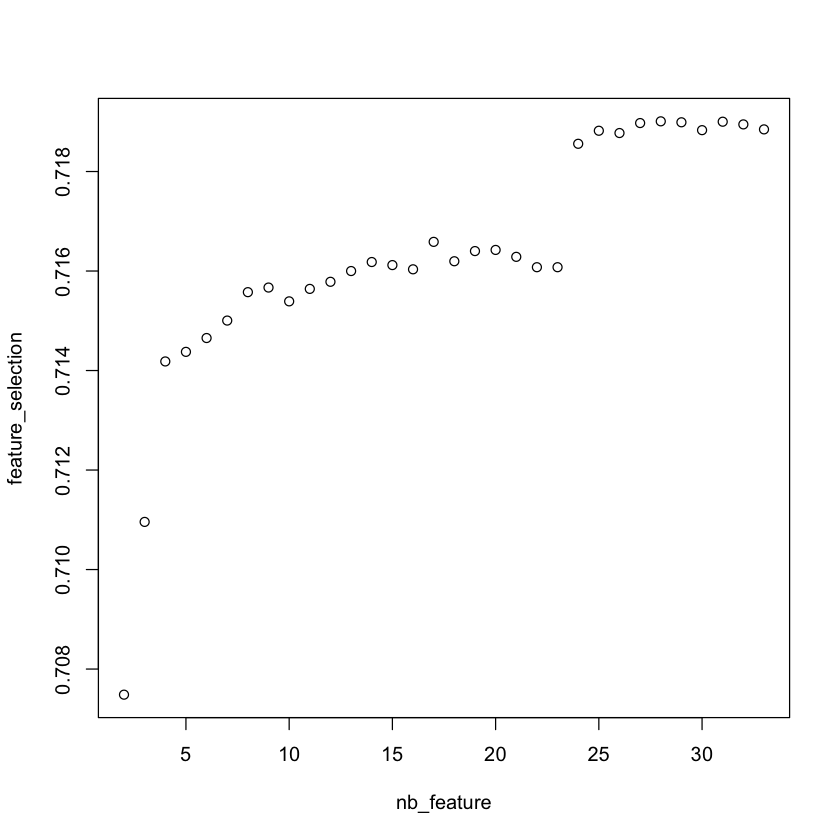

In [117]:
set.seed(2)

k = 10
accuracy_matrix <- matrix(0, nrow = (length(seq(2,length(rankingNN.lin),1))), ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = (length(seq(2,length(rankingNN.lin),1))-1), style = 3)

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])


for (l in seq(2,length(rankingNN.lin),1)){
    X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X <- X[,rankingNN.lin[1:l]]
    
    Shuffle_idx <- sample(1:nrow(dataNN.lin))
    max <- ceiling(nrow(dataNN.lin)/k)
    splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    tic()
    for (i in 1:k){
        X.test <- X[splits[[i]],]
        y.test <-  y[splits[[i]],]
        X.train <- X[-splits[[i]],]
        y.train <-  y[-splits[[i]],]
    
        X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

        beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
        pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

        cm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:nrow(X.test)){
            cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1
        }
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix[l-1,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
    setTxtProgressBar(pb1, l-1)
    print(mean(accuracy_matrix[l-1,]))
    toc()
}

feature_selection <- accuracy_matrix %*% as.vector(rep(1/k,k))
nb_feature <- seq(2,length(rankingNN.lin),1)
plot(nb_feature,feature_selection)

On peux suprimer tous les feature apres 16 dans rankingNN.lin

In [138]:
rankingNN.lin[c(10,18,29,30,31,32,33)]
colnames(dataNN.lin)[rankingNN.lin[c(10,18,29,30,31,32,33)]]

[1] 12 24 28 15 31 10 32

[1] "has_superstructure_mud_mortar_stone" "roof_type_n"                        
[3] "ground_floor_type_x"                 "has_superstructure_timber"          
[5] "position_j"                          "height_percentage"                  
[7] "position_s"

In [135]:
set.seed(2)

k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

X <- X[,rankingNN.lin[-c(10,18,29,30,31,32,33)]]

for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.7194216


teston d'enlever les feature 4 dans rankingNN.lin

In [40]:
set.seed(2)

k = 10
accuracy_vec <- 1:k

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

X <- X[,rankingNN.lin[c(1,2,3,5,6,7,8,9,10,11,12,13,14,15,16)]]
Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
tic()
for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
print(mean(accuracy_vec))
toc()

  |                                                                      |   0%[1] 0.718656
  |========                                                              |  11%[1] 0.7220122
  |================                                                      |  22%[1] 0.7195818
  |=======================                                               |  33%[1] 0.7172672
  |===============================                                       |  44%[1] 0.7167657
  |=======================================                               |  56%[1] 0.713448
  |===============================================                       |  67%[1] 0.7183473
  |======================================================                |  78%[1] 0.720932
  |==============================================================        |  89%[1] 0.7195432
  |======================================================================| 100%[1] 0.7157411
[1] 0.7182295
2.211 sec elapsed


on remarque que cela baise le score f1 de notre model.

On vas donc s'areter là

### 2.2 Neural network

### 2.3 Random forest

### 2.4 Comparison of models 

# 3. Implementation of an other learning procedure

### 3.1 Gradient boosting tree

### xgboost

In [2]:
library(Matrix)
library(xgboost)
library(ggplot2)
library(lattice)
library(caret)
library(dplyr)
library(tictoc)
library(recipes)


Attachement du package : ‘xgboost’


L'objet suivant est masqué depuis ‘package:dplyr’:

    slice




In [2]:
data.xgb <- read.csv("data_target_encoding.csv",stringsAsFactors = T)
test.xgb <- read.csv("test_target_encoding.csv",stringsAsFactors = T)

Pour proces nos data avec xgboost on vas avoir besoin du forma 'S4'.
On passe d'abord par un one-hot encoding pour par la suite pouvoir appliquer un mRMR avec la variable damage_grade non split.
Si on met directement le dataset sous forme S4 on risque d'avoir des problème pour appliquer mRMR

In [3]:
dummy_data <- dummyVars(" ~ .", data=data.xgb)  
data.xgb <- data.frame(predict(dummy_data, newdata = data.xgb)) 
dummy_test <- dummyVars(" ~ .", data=test.xgb)  
test.xgb <- data.frame(predict(dummy_test, newdata = test.xgb)) 

##### 

In [30]:
dim(data.xgb)

[1] 260601     71

In [24]:
X <- sparse.model.matrix(damage_grade ~ .,data = data.xgb)[,-1]
#test.xgb <- sparse.model.matrix( ~ .,data = test.xgb)[,-1]
y <- as.numeric(data.xgb[,c("damage_grade")]-1)

In [101]:
dim(X)

[1] 260601     70

In [102]:
dim(test.xgb)

[1] 86868    70

In [4]:
f1 <- function(data, lev = NULL, model = NULL) {
    f1_val <- f1_score(data$pred,data$obs)
    names(f1_val) <- c("F1")
    f1_val
}

f1_score <- function(predicted, expected) {
    predicted <- factor(as.character(predicted), levels=c('0','1','2'))
    expected  <- as.factor(expected)
    cm = as.matrix(table(expected, predicted))
    
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    f1 <-  (2*P_micro*R_micro)/(P_micro+R_micro)
    f1
}

On teste le model avec les paramétre de base 

In [67]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = 100,
  max_depth = 6,
  eta = 0.3,
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()

795.379 sec elapsed


In [68]:
xgb_model$results

,nrounds,max_depth,eta,gamma,colsample_bytree,min_child_weight,subsample,F1,F1SD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,100,6,0.3,0,1,1,1,0.7617277,0.001100707


Xgboost 5cv sans tuning 

In [80]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

Shuffle_idx <- sample(1:nrow(X))
max <- ceiling(nrow(X)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)

for (i in 1:k){
    
    X.test <- X[splits[[i]],]
    y.test <- y[splits[[i]]]
    X.train <- X[-splits[[i]],]
    y.train <- y[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.train,
    y = as.factor(y.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
}

mean(accuracy_vec)
toc()

  |                                                                      |   0%[1] 0.762706
  |==================                                                    |  25%[1] 0.7585618
  |===================================                                   |  50%[1] 0.7631089
  |====================================================                  |  75%[1] 0.7621112
  |======================================================================| 100%[1] 0.761383


[1] 0.7615742

663.61 sec elapsed


xgboost 5cv subsample

In [81]:
set.seed(2)

k = 5
accuracy_vec.sub <- array(0,k)

Shuffle_idx <- sample(1:nrow(data.xgb))
max <- ceiling(nrow(data.xgb)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)

for (i in 1:k){
    
    data.test <- data.xgb[splits[[i]],]
    data.train <- data.xgb[-splits[[i]],]
    
    idx_damage_grade_1 <- which(data.train$damage_grade == 1)
    n_sub <- length(idx_damage_grade_1)

    idx_damage_grade_2 <- sample(which(data.train$damage_grade == 2),n_sub)
    idx_damage_grade_3 <- sample(which(data.train$damage_grade == 3),n_sub)
    
    data.sub.train <- rbind(data.train[idx_damage_grade_1,],data.train[idx_damage_grade_2,],data.train[idx_damage_grade_3,])
    

    X.sub.train <- sparse.model.matrix(damage_grade ~ .,data = data.sub.train)[,-1]
    X.test <- sparse.model.matrix(damage_grade ~ .,data = data.test)[,-1]
    y.sub.train <- as.numeric(data.sub.train[,c("damage_grade")]-1)
    y.test <- as.numeric(data.train[,c("damage_grade")]-1)
    
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model.sub <- caret::train(
    x = X.sub.train,
    y = as.factor(y.sub.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model.sub, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    
    accuracy_vec.sub[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
}

mean(accuracy_vec.sub)
toc()

  |                                                                      |   0%[1] 0.3908789
  |==================                                                    |  25%[1] 0.3942365
  |===================================                                   |  50%[1] 0.3903993
  |====================================================                  |  75%[1] 0.3939487
  |======================================================================| 100%[1] 0.3937679


[1] 0.3926462

198.356 sec elapsed


xgboost 5cv oversample

In [82]:
set.seed(2)

k = 5
accuracy_vec.over <- array(0,k)

Shuffle_idx <- sample(1:nrow(data.xgb))
max <- ceiling(nrow(data.xgb)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)

for (i in 1:k){
    data.test <- data.xgb[splits[[i]],]
    data.train <- data.xgb[-splits[[i]],]
    
    idx_damage_grade_1 <- which(data.train$damage_grade == 1)
    idx_damage_grade_2 <- which(data.train$damage_grade == 2)
    idx_damage_grade_3 <- which(data.train$damage_grade == 3)
    
    n_over1 <- length(idx_damage_grade_2)-length(idx_damage_grade_1)
    n_over3 <- length(idx_damage_grade_2)-length(idx_damage_grade_3)
    
    idx_damage_grade_1 <- sample(idx_damage_grade_1,n_over1,replace=TRUE)
    idx_damage_grade_3 <- sample(idx_damage_grade_3,n_over3,replace=TRUE)
    
    data.over.train <- rbind(data.train[idx_damage_grade_1,],data.train[idx_damage_grade_2,],data.train[idx_damage_grade_3,])
    

    X.over.train <- sparse.model.matrix(damage_grade ~ .,data = data.over.train)[,-1]
    X.test <- sparse.model.matrix(damage_grade ~ .,data = data.test)[,-1]
    y.over.train <- as.numeric(data.over.train[,c("damage_grade")]-1)
    y.test <- as.numeric(data.train[,c("damage_grade")]-1)
    
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model.over <- caret::train(
    x = X.over.train,
    y = as.factor(y.over.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model.over, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    
    accuracy_vec.over[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
}

mean(accuracy_vec.over)
toc()

  |                                                                      |   0%[1] 0.433357
  |==================                                                    |  25%[1] 0.4340669
  |===================================                                   |  50%[1] 0.4315535
  |====================================================                  |  75%[1] 0.4338175
  |======================================================================| 100%[1] 0.4353858


[1] 0.4336361

853.377 sec elapsed


- Feature selection 

In [5]:
set.seed(2)

n<-ncol(data.xgb)
targets<-which(grepl('damage_grade',colnames(data.xgb)))
correlation<-abs(cor(data.xgb[,-targets,drop=F],data.xgb[,targets,drop=F]))
selected<-c()
candidates<-1:n

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-abs(cor(data.xgb[,selected,drop=F],data.xgb[,candidates,drop=F]))
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
ranking.xgb <- selected
ranking.xgb
colnames(data.xgb)[ranking.xgb]

[1]  5 15  1 17  3 21 44 18 24 60  2 46 47 54  7 50 53  4 16 59 22 56 20  6 63
[26] 55 62 27 29 35 34 48 70 64  9  8 28 52 36 23 41 45 43 12 67 68 51 66 39 40
[51] 65 26 30 38 69 19 58 14 42 61 11 57 32 31 37 25 13 10 49 33

[1] "geo_level_3_mean_damage"               
 [2] "foundation_type.i"                     
 [3] "geo_level_1_mean_damage"               
 [4] "foundation_type.u"                     
 [5] "geo_level_2_mean_damage"               
 [6] "roof_type.x"                           
 [7] "plan_configuration.u"                  
 [8] "foundation_type.w"                     
 [9] "ground_floor_type.v"                   
[10] "count_families"                        
[11] "geo_level_1_sd_damage"                 
[12] "has_superstructure_mud_mortar_stone"   
[13] "has_superstructure_stone_flag"         
[14] "has_superstructure_rc_engineered"      
[15] "count_floors_pre_eq"                   
[16] "has_superstructure_cement_mortar_brick"
[17] "has_superstructure_rc_non_engineered"  
[18] "geo_level_2_sd_damage"                 
[19] "foundation_type.r"                     
[20] "legal_ownership_status.w"              
[21] "ground_floor_type.f"                   
[22] "legal_ownership_status.a"              
[23] "roof_type.q"                           
[24] "geo_level_3_sd_damage"                 
[25] "has_secondary_use_rental"              
[26] "has_superstructure_other"              
[27] "has_secondary_use_hotel"               
[28] "other_floor_type.j"                    
[29] "other_floor_type.s"                    
[30] "plan_configuration.a"                  
[31] "position.t"                            
[32] "has_superstructure_cement_mortar_stone"
[33] "has_secondary_use_other"               
[34] "has_secondary_use_institution"         
[35] "area_percentage"                       
[36] "age"                                   
[37] "other_floor_type.q"                    
[38] "has_superstructure_bamboo"             
[39] "plan_configuration.c"                  
[40] "ground_floor_type.m"                   
[41] "plan_configuration.o"                  
[42] "has_superstructure_adobe_mud"          
[43] "plan_configuration.s"                  
[44] "land_surface_condition.o"              
[45] "has_secondary_use_health_post"         
[46] "has_secondary_use_gov_office"          
[47] "has_superstructure_timber"             
[48] "has_secondary_use_industry"            
[49] "plan_configuration.m"                  
[50] "plan_configuration.n"                  
[51] "has_secondary_use_school"              
[52] "ground_floor_type.z"                   
[53] "other_floor_type.x"                    
[54] "plan_configuration.f"                  
[55] "has_secondary_use_use_police"          
[56] "roof_type.n"                           
[57] "legal_ownership_status.v"              
[58] "foundation_type.h"                     
[59] "plan_configuration.q"                  
[60] "has_secondary_use_agriculture"         
[61] "land_surface_condition.n"              
[62] "legal_ownership_status.r"              
[63] "position.o"                            
[64] "position.j"                            
[65] "plan_configuration.d"                  
[66] "ground_floor_type.x"                   
[67] "land_surface_condition.t"              
[68] "height_percentage"                     
[69] "has_superstructure_mud_mortar_brick"   
[70] "position.s"

In [8]:
length(ranking.xgb)

[1] 70

!!!!!! Eviter de run la cellule suivante !!!!!

In [9]:
set.seed(2)

k = 5
accuracy_matrix.xgb <- matrix(0, nrow = length(seq(2,length(ranking.xgb),2)), ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = length(seq(2,length(ranking.xgb),2)), style = 3)
for (l in seq(2,length(ranking.xgb),2)){
    
    X.f  <- X[,ranking.xgb[1:l]]
    
    Shuffle_idx <- sample(1:nrow(X.f))
    max <- ceiling(nrow(X.f)/k)
    splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 
    
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.f.test <- X.f[splits[[i]],]
        y.test <- y[splits[[i]]]
        X.f.train <- X.f[-splits[[i]],]
        y.train <- y[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = 100,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.f.train,
        y = as.factor(y.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.f.test)
        ll <- length(y.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix.xgb[l/2,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    setTxtProgressBar(pb1, l/2)
    print(mean(accuracy_matrix.xgb[l/2,]))
    toc()
}

  |                                                                      |   0%[1] 0.7403925
  |==================                                                    |  25%[1] 0.7358838
  |===================================                                   |  50%[1] 0.7414286
  |====================================================                  |  75%[1] 0.7406228
  |======================================================================| 100%[1] 0.7391638
  |                                                                      |   0%[1] 0.7394983
56.896 sec elapsed
  |                                                                      |   0%[1] 0.7430019
  |==================                                                    |  25%[1] 0.7402966
  |===================================                                   |  50%[1] 0.7412176
  |====================================================                  |  75%[1] 0.7439612
  |================================================

  |======================================================================| 100%[1] 0.756471
  |=============================                                         |  41%[1] 0.7551429
  |                                                                      |   0%[1] 0.7546478
  |==================                                                    |  25%[1] 0.7539188
  |===================================                                   |  50%[1] 0.7558566
  |====================================================                  |  75%[1] 0.7586769
  |======================================================================| 100%[1] 0.7545714
  |===============================                                       |  44%[1] 0.7555343
  |                                                                      |   0%[1] 0.7580822
  |==================                                                    |  25%[1] 0.7567967
  |===================================                                 

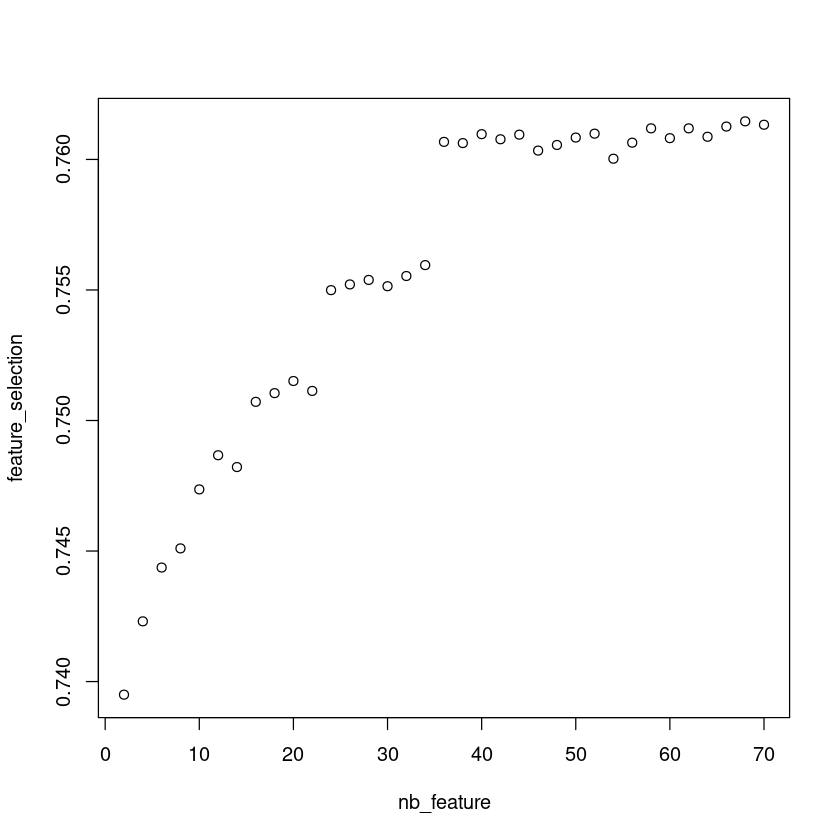

In [10]:
feature_selection <- as.matrix(accuracy_matrix.xgb) %*% as.vector(rep(1/k,k))
nb_feature <- seq(2,length(ranking.xgb),2)
plot(nb_feature,feature_selection)

In [12]:
write.csv(as.data.frame(accuracy_matrix.xgb), file = "accuracy_matrix_feature_selection_xgb.csv", row.names = FALSE)

In [14]:
set.seed(2)

k = 5
accuracy_vec <- 1:k

tic()

X.f  <- X[,ranking.xgb[-c(13,14,21,22,45,46,51,52)]]
    
Shuffle_idx <- sample(1:nrow(X.f))
max <- ceiling(nrow(X.f)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 
    
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
for (i in 1:k){
    X.f.test <- X.f[splits[[i]],]
    y.test <- y[splits[[i]]]
    X.f.train <- X.f[-splits[[i]],]
    y.train <- y[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )
        
    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.f.train,
    y = as.factor(y.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.f.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}
mean(accuracy_vec)
toc()

  |                                                                      |   0%[1] 0.7624566
  |==================                                                    |  25%[1] 0.7593101
  |===================================                                   |  50%[1] 0.7641833
  |====================================================                  |  75%[1] 0.76167
  |======================================================================| 100%[1] 0.7605772


[1] 0.7616394

292.031 sec elapsed


- On commence le tuining de paramétre 

In [6]:
data.xgb <- data.xgb[,setdiff(colnames(data.xgb),ranking.xgb[c(13,14,21,22,45,46,51,52)])]
test.xgb <- test.xgb[,setdiff(colnames(test.xgb),ranking.xgb[c(13,14,21,22,45,46,51,52)])]

In [7]:
X <- sparse.model.matrix(damage_grade ~ .,data = data.xgb)[,-1]
#test.xgb <- sparse.model.matrix( ~ .,data = test.xgb)[,-1]
y <- as.numeric(data.xgb[,c("damage_grade")]-1)

In [7]:
f1 <- function(data, lev = NULL, model = NULL) {
    f1_val <- f1_score(data$pred,data$obs)
    names(f1_val) <- c("F1")
    f1_val
}

f1_score <- function(predicted, expected) {
    predicted <- factor(as.character(predicted), levels=c('0','1','2'))
    expected  <- as.factor(expected)
    cm = as.matrix(table(expected, predicted))
    
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    f1 <-  (2*P_micro*R_micro)/(P_micro+R_micro)
    f1
}

In [10]:
tuneplot <- function(x, probs = .1) {
  ggplot(x) +
    coord_cartesian(ylim = c(quantile(x$results$F1, probs = probs), max(x$results$F1)))
}

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (1:9)*20+50,
  max_depth = c(5,7,10,12),
  eta = c(0.1,0.15,0.2,0.3),
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_1 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_1$results
xgb_model_1$bestTune

In [ ]:
tuneplot(xgb_model_1)

In [ ]:
max_depth_op <- xgb_model_1$bestTune$max_depth
eta_op <- xgb_model_1$bestTune$eta
nrounds_op <- xgb_model_1$bestTune$nrounds
rm(xgb_model_1)

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (((nrounds_op/5)-4):((nrounds_op/5)+4))*5,
  max_depth = (max_depth_op - 1):(max_depth_op + 1),
  eta = eta_op,
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = c(1,2,4,8),
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_2 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_2$results
xgb_model_2$bestTune

In [ ]:
tuneplot(xgb_model_2)

In [ ]:
max_depth_op <- xgb_model_2$bestTune$max_depth
min_child_weight_op <- xgb_model_2$bestTune$min_child_weight
nrounds_op <- xgb_model_2$bestTune$nrounds
rm(xgb_model_2)

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (((nrounds_op/5)-2):((nrounds_op/5)+2))*5,
  max_depth = max_depth_op,
  eta = eta_op,
  gamma = 0,
  colsample_bytree = c(0.5,0.7,0.9,1),
  min_child_weight = min_child_weight_op,
  subsample = c(0.5,0.7,0.9,1)
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_3 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_3$results
xgb_model_3$bestTune

In [ ]:
tuneplot(xgb_model_3)

In [ ]:
colsample_bytree_op <- xgb_model_3$bestTune$colsample_bytree 
subsample_op <- xgb_model_3$bestTune$subsample
nrounds_op <- xgb_model_3$bestTune$nrounds
rm(xgb_model_3)

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (((nrounds_op/5)-2):((nrounds_op/5)+2))*5,
  max_depth = max_depth_op,
  eta = eta_op,
  gamma = c(0, 0.05, 0.1, 0.5, 0.7, 0.9, 1.0),
  colsample_bytree = colsample_bytree_op,
  min_child_weight = min_child_weight_op,
  subsample = subsample_op
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_4 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_4$results
xgb_model_4$bestTune

In [ ]:
tuneplot(xgb_model_4)

In [ ]:
gamma_op <- xgb_model_4$bestTune$gamma
nrounds_op <- xgb_model_4$bestTune$nrounds
rm(xgb_model_4)

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = nrounds_op,
  max_depth = max_depth_op,
  eta = eta_op,
  gamma = gamma_op,
  colsample_bytree = colsample_bytree_op,
  min_child_weight = min_child_weight_op,
  subsample = subsample_op
)

train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_op <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()

In [108]:
X.f  <- X[,ranking.xgb[-two_feature_remove]]

grid_default <- expand.grid(
    nrounds = 220,
    max_depth = 7,
    eta = 0.15,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )
        
    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model_pred <- caret::train(
    x = X.f,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

In [109]:
pred_full <- predict(xgb_model_pred, test.xgb)
submission_format[2] <- as.numeric(pred_full)
write.csv(submission_format, file = "submission_format_xgboost_tuning_2.csv", row.names = FALSE)

# 4. Submit our prediction to driven data 

# 5. Ranking of the features in terms of relevance

# 6. Conclusion 